# Lipschitz Neural Networks

## Theory behind Lipschitz Neural Networks

### Definitions and properties

>**Definition** A function $f$: $\mathbb{R}^n \rightarrow \mathbb{R}^m$ is defined as $k$-Lipschitz if for every $x$, $y$, the Euclidean distance between the output is no greater than the Euclidian distance between the inputs:

\begin{equation*}
    \left\Vert f(x) - f(y) \right\Vert_2 \leq k \left\Vert x - y \right\Vert_2
\end{equation*}

For a $1$-Lipschitz function, we then have $k=1$, 

\begin{equation*}
    \left\Vert f(x) - f(y) \right\Vert_2 \leq \left\Vert x - y \right\Vert_2
\end{equation*}

This means that if $x$ and $y$ are close to each other, then their predictions, $f(x)$ and $f(y)$ are close to each other as well. A Lipschitz neural network is a neural network that satisfies this property. The robustness of the neural network is now a mathematical guarantee, rather than a statistical observation.

A $1$-Lipschitz function has the interesting property that the $\mathcal{l}_2$-norm of its gradient is at most 1. 

**Proof** Let's assume a differentiable function $f$, that is $1$-Lipschitz. We want to find the magnitude of the gradient at a specific point $x \in \mathbb{R}^n$, denoted as $\left\Vert \nabla f(x) \right\Vert_2$.

Let v be a small step vector. By linear approximation, we know that, 

\begin{align*}
    & f(x + v) \approx f(x) + \nabla f(x) v \\
    \Leftrightarrow \quad & f(x + v) - f(x) \approx \nabla f(x) v
\end{align*}

Let $y=x+v$. By definition of a $1$-Lipschitz function, we have, 

\begin{align*}
    & \left\Vert f(x + v) - f(x) \right\Vert_2 = \left\Vert x + v - v \right\Vert_2 \\
    \Leftrightarrow \quad & \left\Vert \nabla f(x) v \right\Vert_2 = \left\Vert v \right\Vert_2
\end{align*}

The inequality must hold for any vector $v$. Thus, in order to find the size of the gradient, we should choose the vector for which the change is maximized. We know that the dot product $\nabla f(x) v$ is maximized when the vector $v$ points exactly in the same direction as the gradient: 

\begin{equation*}
    v = \epsilon \frac{\nabla f(x)}{\left\Vert \nabla f(x) \right\Vert}
\end{equation*}

Substituting this into the previous equality, 

\begin{align*}
    & \left\Vert \nabla f(x) \epsilon \frac{\nabla f(x)}{\left\Vert \nabla f(x) \right\Vert_2} \right\Vert_2 \leq \left\Vert \epsilon \frac{\nabla f(x)}{\left\Vert f(x) \right\Vert_2} \right\Vert_2 \\
    \Leftrightarrow \quad & \epsilon \left\Vert \nabla f(x) \right\Vert_2 \leq \epsilon \\
    \Leftrightarrow \quad & \left\Vert \nabla f(x) \right\Vert_2 \leq 1
\end{align*}

Hence, the $\mathcal{l}_2$-norm of the gradient of a $1$-Lipschitz function is at most equal to 1. This property ensures that the gradient will not explode, which is one of the main concerns when training a neural network. 

### Methods

To apply Lipschitz constraints to neural networks, we constrain the Lipschitz constant of each layer. Feedforward neural networks can be described as a composition of functions $f^{(1)}, \dots, f^{(n)}$ connected in chain to form the output $f(x) = f^{(n)}(\dots f^{(2)}(f^{(1)}(x)))$. Each function $f^{(i)}$ represents a layer.  

Let $k_1, \dots, k_n$ be the Lipschitz constants for the functions $f^{(1)}, \dots, f^{(n)}$. Then, 

\begin{equation*}
    \left\Vert f(x_1) - f(x_2) \right\Vert \leq k_1 \times \dots \times k_n \left\Vert x_1 - x_2 \right\Vert
\end{equation*}

Recall that dense layers are expressed as $f(x) = \phi(Wx)$ where $W$ is a weight matrix, and $\phi$ a nonlinear transformation. To achieve this property, there are different methods such as Spectral Normalisation or Björck Orthonormalization.

#### Spectral Normalisation

>**Definition** Suppose a linear function $A$: $\mathbb{R}^n \rightarrow \mathbb{R}^m$. The spectral norm of this function is defined as the largest singular value of the matrix $A$, i.e., the square root of the largest eigenvalue of $A^{\top}A$. 

We have that the Lipschitz constant of a linear function is its spectral norm, i.e. its largest singular value.

The objective is that every linear transformations of our neural network, which correspond to a weight matrix $W$, has a spectral norm $\sigma(W) \leq 1$ such that it is $1$-Lipschitz. In order to do this, Spectral Normalization simply replaces the weight matrix $W$ by $\frac{W}{\sigma(W)}$. The main concern is then, how to compute efficiently $\sigma(W)$ ? 

Let a linear map $W$: $\mathbb{R}^n \rightarrow \mathbb{R}^m$. Take a random vector in the domain of $W$, $v \in \mathbb{R}^n$, and another vector in the codomain of $W$, $u \in \mathbb{R}^m$.

Consider the matrix $W^{\top}W$: $\mathbb{R}^n \rightarrow \mathbb{R}^n$. We use the power iteration algorithm using the random vector $v$ defined above. We have the following recurrence relation, 

\begin{equation*}
    v_{t+1} = \frac{W^{\top}W v_t}{\left\Vert W^{\top}W v_t \right\Vert_2}
\end{equation*}

The unroll relation is given by, 

\begin{equation*}
    v_t = \frac{(W^{\top}W)^t v}{\left\Vert (W^{\top}W)^t v \right\Vert_2}
\end{equation*}

Let $\lambda_1, \dots, \lambda_n$ the eigenvalues of $W^{\top}W$ in descending order, and $e_1, \dots, e_n$ the corresponding eigenvectors. By the spectral theorem, we can write $v$ in an orthonormal basis of eigenvectors of $W^{\top}W$, $v = \sum_{i} v_i e_i$. The power iteration is equal to, 

\begin{align*}
    v_t & = \frac{(W^{\top}W)^t \sum_{i} v_i e_i}{\left\Vert (W^{\top}W)^t \sum_{i} v_i e_i \right\Vert_2} \\
    & = \frac{\sum_{i} v_i \lambda_i^t e_i}{\left\Vert \sum_{i} v_i \lambda_i^t e_i \right\Vert_2} \\
    & = \frac{v_1 \lambda_1^t \sum_{i} \frac{v_i}{v_1} (\frac{\lambda_i}{\lambda_1})^t e_i}{\left\Vert v_1 \lambda_1^t \sum_{i} \frac{v_i}{v_1} (\frac{\lambda_i}{\lambda_1})^t e_i \right\Vert_2}
\end{align*}

Since $\lambda_1$ is the largest eigenvalue of $W^{\top}W$, then $\frac{\lambda_i}{\lambda_1} < 1$ for $i > 1$, and so, $\lim_{t \rightarrow \infty} (\frac{\lambda_i}{\lambda_1})^t = 0$. Hence, 

\begin{align*}
    \lim_{t \rightarrow \infty} v_t & = \frac{v_1 \lambda_1^t e_1}{\left\Vert v_1 \lambda_1^t e_1 \right\Vert_2} \\
    & = \frac{v_1 \lambda_1^t}{v_1 \lambda_1^t \left\Vert e_1 \right\Vert_2} e_1 \\
    & = e_1
\end{align*}

since $e_1, \dots, e_n$ is an orthonormal basis, $\left\Vert e_1 \right\Vert_2 = 1$. Hence, since $\lim_{t \rightarrow \infty} v_t = e_1 := v$, then $v$ is equal to the eigenvector associated to the eigenvalue $\lambda_1$, and so, $(W^{\top}W)v = \lambda_1 v$.

We have, 

\begin{align*}
    \left\Vert Wv \right\Vert_2^2 & = (Wv)^{\top}(Wv) \\
    & = v^{\top} W^{\top} Wv \\
    & = v^{\top} \lambda_1 v \\
    & = \lambda_1 v^{\top}v
\end{align*}

since $v$ is normalized in the algorithm, it is a unit vector, and thus, $v^{\top}v = \left\Vert v \right\Vert_2^2 = 1$. Hence, 

\begin{align*}
    & \left\Vert Wv \right\Vert_2^2 = \lambda_1 \\
    \Leftrightarrow \quad & \left\Vert Wv \right\Vert_2 = \sqrt{\lambda_1} = \sigma(W)
\end{align*}

In practice, computing $W^{\top}W$ takes a lot of memory and time. To avoid calculating this matrix, we rely on the property of matrix multiplication: $(W^{\top}W)v_t = W^{\top}(Wv_t)$, to define an intermediate computation, $u_t = \frac{Wv_t}{\left\Vert Wv_t \right\Vert}$. Thus, the power iteration algorithm proceeds as follows, 

\begin{align*}
    & u_t = \frac{Wv_t}{\left\Vert Wv_t \right\Vert} \\
    & v_{t+1} = \frac{W^{\top} u_t}{\left\Vert W^{\top} u_t \right\Vert}
\end{align*}

Upon convergence, we have the dot product, 

\begin{equation*}
    u^{\top} W v = \left\Vert u \right\Vert_2 \left\Vert Wv \right\Vert_2 \cos(\theta)
\end{equation*}

Since $u$ and $Wv$ point in the exact same direction, due to the normalization of u, the angle $\theta$ is equal to $0$. And since $u$ has length $1$, $\left\Vert u \right\Vert_2 = 1$. Hence,

\begin{equation*}
    u^{\top} Wv = \left\Vert Wv \right\Vert_2 = \sqrt{\lambda_1} = \sigma(W)
\end{equation*}

This is a more computationally efficient algorithm, since it avoids explicitly calculating the matrix $W^{\top}W$. 

#### Björck Orthonormalization

In the spectral normalization, we are only constraining $\sigma(W)$, the largest singular value. The problem is that, the others singular values may decay toward $0$ during training, reducing the effective rank of the weight matrix and limiting the network's expressing power.

To solve this problem, we can employ the Björck Orthonormalization, which is based on the Newton-Schulz iteration. The goal of this algorithm is to iteratively transform the weight matrix towards the closest orthogonal matrix, such that all the singular values are exactly $1$.

>**Definition** The polar decomposition states that any square matrix $A$ can be decomposed into two parts: $A = UP$ where $P$ is a positive semi-definite matrix, and $U$ is an orthogonal matrix. 

The Newton-Schulz iteration is a fixed-point method useful for matrix inversion, or polar decomposition. Since we want to transform the weight matrix $W$ toward the closest orthogonal matrix, we are then interested in finding the part $U$ of $W$. For a square matrix $A \in \mathbb{R}^{n \times n}$, the iteration is written as, 

\begin{align*}
    & A_0 = A \\
    & A_{k+1} = \frac{3}{2} A_k - \frac{1}{2}A_k A_k^{\top} A_k
\end{align*}

This fixed-point mapping converges quadratically to the orthogonal part $U$ of the polar decomposition of the matrix $A$. Hence, this iterative process forces the weight matrix to satisfy $W^{\top}W \approx I$, ensuring $\left\Vert W \right\Vert_2 \approx 1$, while maintaining high rank. 

### Activation functions

The standard activation functions like ReLU are $1$-Lipschitz, since their derivative is either 0 or 1, so we could use it for the Lipschitz neural network. However, the regions where the derivative is equal to 0 cause information loss. In classic feedforward neural networks, if there is a loss of information, i.e. some neurons are set equal to 0, then the next layer will be able to compensate by having very large weights. But in Lipschitz neural networks, we are using a strict constraint on our weights: the spectral norm of the weight matrix must be less than or equal to $1$. Hence, the next layer cannot compensate for this loss of information. 

The GroupSort activation function separates the pre-activations into groups of size $k$, and sorts each group in ascending order. The sorting operation is $1$-Lipschitz, and preserves the norm of the input vector, since it is just a permutation. This activation function never zeros out a value, so it solves the information loss problem. A GroupSort with $k=2$ is defined as,

\begin{equation*}
    \text{GroupSort2}([x_1, x_2]) = [\min(x_1, x_2), \max(x_1, x_2)]
\end{equation*}

Furthermore, the GroupSort activation function is Gradient Norm Preserving (GNP). This means that it preserves the magnitude of the gradient vector, as it passes backward through the layer. 

### Loss function

We will use the Mean Squared Error (MSE) since it is the basic loss function for regression tasks. It is defined as, 

\begin{equation*}
    \text{MSE}(y, \hat{y}) = \frac{1}{N} \left\Vert y - \hat{y} \right\Vert_2^2
\end{equation*}

The only problem is that MSE assumes Gaussian errors with constant variance, which is a very strong assumption, especially for volatility. 

## Implementation of the Lipschitz Neural Network

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

### Data

In [2]:
data = pd.read_csv("SPY_daily_data.csv")

In [3]:
def garman_klass_volatility(data):
    """
    Computes Garman-Klass volatility estimator.
    
    This range-based estimator is far more efficient 
    than close-to-close variance.
    Formula: sigma^2 = 0.5 * (ln(H/L))^2 - (2*ln(2) - 1) * (ln(C/O))^2

    Parameters
    ----------
    data : pd.DataFrame
        A DataFrame containing the columns 'Open', 'High', 'Low', and 'Close'.
        Prices must be strictly positive to avoid logarithm errors.

    Returns
    -------
    pd.Series
        A pandas Series containing the daily Garman-Klass volatility (standard deviation).
        Note: The output is per-period (e.g., daily) volatility and is not annualized.
    """
    # Avoid log(0) errors with a small epsilon if necessary, 
    # though valid OHLC data should not have 0 high/low/open/close.
    log_hl = np.log(data['High'] / data['Low'])
    log_co = np.log(data['Close'] / data['Open'])
    
    rs = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2
    return np.sqrt(rs)

In [4]:
data['gk_vol'] = garman_klass_volatility(data)

data = data.dropna()

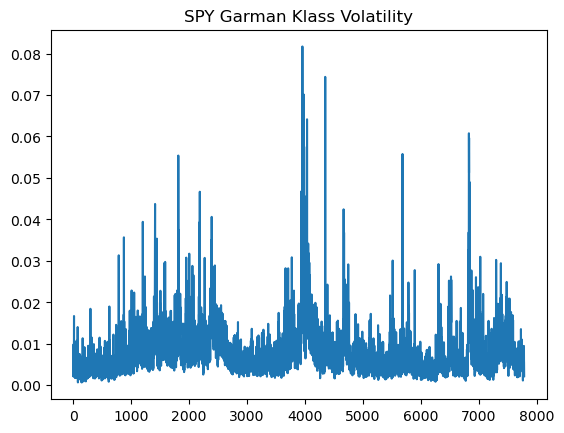

In [5]:
plt.plot(data['gk_vol'])
plt.title(f"SPY Garman Klass Volatility")
plt.show()

In [6]:
def create_sequences(data_series, seq_length):
    """
    Transforms a time series into input/output pairs.

    This function applies a sliding window approach to create sequences of data 
    (features) and their corresponding immediate next value (target). This is 
    commonly used to prepare data for Recurrent Neural Networks (RNNs) or LSTMs.

    Parameters
    ----------
    data_series : pd.Series or pd.DataFrame
        The input time series data. Must have a `.values` attribute 
        (e.g., pandas objects).
    seq_length : int
        The number of time steps to look back (the window size). 
        This determines the length of each input sequence X.

    Returns
    -------
    tuple of (np.ndarray, np.ndarray)
        - **X (inputs):** An array of shape `(n_samples, seq_length)`.
          Contains the historical data sequences.
        - **y (targets):** An array of shape `(n_samples,)`.
          Contains the target value immediately following each sequence.
    """
    xs, ys = [], []
    # Convert to numpy array first
    data_array = data_series.values
    
    for i in range(len(data_array) - seq_length):
        x_window = data_array[i:i+seq_length]
        y_target = data_array[i+seq_length]
        xs.append(x_window)
        ys.append(y_target)
    
    return np.array(xs), np.array(ys)

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

SEQ_LENGTH = 21 # look back of 21 days
vol_data = np.array(data['gk_vol']).reshape(-1, 1)

# Scale data
scaler = MinMaxScaler(feature_range=(-1, 1))
vol_scaled = scaler.fit_transform(vol_data)

# create X and y
X, y = create_sequences(pd.Series(vol_scaled.flatten()), SEQ_LENGTH)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

In [8]:
from torch.utils.data import Dataset

class TabularDataset(Dataset):
    """
    A custom PyTorch Dataset for tabular data (regression or classification).

    This class serves as an adapter between raw NumPy arrays and the PyTorch 
    DataLoader. It converts input data into float32 tensors on demand.

    Parameters
    ----------
    X : np.ndarray
        The feature matrix with shape `(n_samples, n_features)`.
    y : np.ndarray
        The target vector with shape `(n_samples,)` or `(n_samples, n_outputs)`.

    Returns
    -------
    tuple of (torch.Tensor, torch.Tensor)
        A tuple containing:
        - **features:** A tensor of shape `(n_features,)`.
        - **target:** A tensor of scalar shape or `(n_outputs,)`.
    """
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.float32)
        )
    
    def __len__(self):
        return len(self.X)

In [9]:
train_tabulardataset = TabularDataset(X_train, y_train)
val_tabulardataset = TabularDataset(X_test, y_test)

### Train function

In [10]:
from typing import Any
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error

def train_regressor(
        model: nn.Module,
        optimizer: torch.optim.Optimizer,
        scaler: Any,
        train_loader: DataLoader,
        valid_loader: DataLoader,
        nb_epoch: int,
        criterion: nn.Module,
        batch_size: int = 16,
        device: torch.device = torch.device("cuda:0"),
        verbose: bool = True
) -> None:
    """
    Executes the training loop for a PyTorch regression model and visualizes results.

    This function handles the full lifecycle of a training run: it iterates through 
    epochs, manages training/validation phases, computes backpropagation, and finally 
    evaluates the model on the full validation set to generate performance plots.

    Parameters
    ----------
    model : nn.Module
        The PyTorch neural network model to train.
    optimizer : torch.optim.Optimizer
        The optimizer algorithm (e.g., Adam, SGD) with registered model parameters.
    scaler : Any
        A fitted scaler object (e.g., sklearn `StandardScaler` or `MinMaxScaler`). 
        Must implement an `inverse_transform` method to convert normalized predictions 
        back to their original scale for plotting.
    train_loader : DataLoader
        Iterator for the training dataset batches.
    valid_loader : DataLoader
        Iterator for the validation dataset batches.
    nb_epoch : int
        The total number of training epochs to run.
    criterion : nn.Module
        The loss function (e.g., `nn.MSELoss`).
    batch_size : int, optional
        The batch size used for loss normalization calculations, by default 16.
    device : torch.device, optional
        The compute device ('cpu' or 'cuda') to move data and model to, 
        by default torch.device("cuda:0").
    verbose : bool, optional
        If True, prints progress and loss metrics after every epoch, by default True.

    Returns
    -------
    Tuple[List[float], List[float]]
        A tuple containing two lists:
        - **train_loss:** History of average training loss per epoch.
        - **val_loss:** History of average validation loss per epoch.
    """
    loaders = {
        "train": train_loader,
        "validation": valid_loader
    }
    model.to(device)
    
    train_loss = []
    val_loss = []

    for epoch in range(1, nb_epoch+1):
        if verbose:
            print("-"*80)

        for phase in ["train", "validation"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0

            for sample in loaders[phase]:
                # unpack batch
                data, label = sample

                # move tensors to device
                data, label = data.to(device), label.to(device)

                # zero the gradients
                optimizer.zero_grad()

                # forward pass
                with torch.set_grad_enabled(phase == "train"):
                    # 'model(data)' runs the forward pass through the network, 
                    # which a prediction store in the variable 'pred_label'.
                    # Then, the loss is computed to compare the prediction and
                    # the real value.
                    
                    output = model(data) # forward propagation
                    pred_label = output.squeeze(-1) # model prediction
                    loss = criterion(pred_label, label) # compute loss

                    if phase == "train":
                        # if we are in the train phase, then the gradient is
                        # computed, and the weights are updated. 

                        loss.backward() # compute gradients
                        optimizer.step() # update weights
                
                running_loss += loss.item()

            # compute epoch loss
            epoch_loss = running_loss / (len(loaders[phase].dataset) / batch_size)

            # save losses
            if phase == "train":
                train_loss.append(epoch_loss)
            else:
                val_loss.append(epoch_loss)

            if verbose:
                print(
                    f"Epoch number: {epoch}, phase: {phase}, Loss value: {epoch_loss:.4f}"
                )
    
    X_val_list = []
    y_val_list = []

    for X_batch, y_batch in valid_loader:
        X_val_list.append(X_batch)
        y_val_list.append(y_batch)

    # concatenate all batches
    X_val = torch.cat(X_val_list, dim=0).to(device)
    y_val = torch.cat(y_val_list, dim=0).to(device)

    # get predictions for the entire validation set
    with torch.no_grad():
        y_pred = model(X_val).cpu().numpy()
    y_val_np = y_val.cpu().numpy()

    # plot training and validation set
    fig, (axe1, axe2) = plt.subplots(2, figsize=(10, 8))
    fig.suptitle('Training and validation statistics')

    y_pred = model(X_val).detach().cpu().numpy()
    axe1.plot(np.arange(len(train_loss)), train_loss, label="train Loss function")
    axe1.plot(np.arange(len(val_loss)), val_loss, label="val Loss function")
    axe1.set_title("Loss function value")
    axe1.legend()

    axe2.scatter(range(len(y_val)), scaler.inverse_transform(y_val.reshape(-1, 1)), label='target')
    axe2.scatter(range(len(y_val)), scaler.inverse_transform(y_pred.reshape(-1, 1)), label='prediction')
    axe2.set_title(f"Prediction // MAE = {mean_absolute_error(y_pred, y_val):.4f}")
    axe2.legend()

    plt.show()

    return train_loss, val_loss

### Simple feedforward neural network

In [11]:
from models import FeedforwardNN
from torch.optim import Adam

# define the model
fnn_model_MSE = FeedforwardNN(in_features=21)

# batch size, need to be small enough to fit in GPU memory,
# large enough for stable gradients.
batch_size = 16

# number of workers for DataLoader, to allows parallel
# loading of data and speeds up training.
num_workers = 0

# DataLoaders
train_dataloader = DataLoader(train_tabulardataset,
                              batch_size=batch_size,
                              shuffle=True,
                              num_workers=num_workers)
val_dataloader = DataLoader(val_tabulardataset,
                            batch_size=batch_size,
                            shuffle=True,
                            num_workers=num_workers)

# Learning rate, here we use the standard one for Adam optimizer.
learning_rate = 1e-3

# Optimizer, Adam adapts learning rate per parameter,
# works well in practice for neural networks
optimizer = Adam(fnn_model_MSE.parameters(), lr=learning_rate)

# Loss function, here regression task so MSE is appropriate
criterion = nn.MSELoss()

# Device, we can use GPU if available.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Number of epochs, need enough epochs to allow convergence;
# need to adjust depending on the dataset. 
nb_epochs = 50

# Verbose
verbose = True

--------------------------------------------------------------------------------
Epoch number: 1, phase: train, Loss value: 0.0422
Epoch number: 1, phase: validation, Loss value: 0.0115
--------------------------------------------------------------------------------
Epoch number: 2, phase: train, Loss value: 0.0101
Epoch number: 2, phase: validation, Loss value: 0.0117
--------------------------------------------------------------------------------
Epoch number: 3, phase: train, Loss value: 0.0098
Epoch number: 3, phase: validation, Loss value: 0.0101
--------------------------------------------------------------------------------
Epoch number: 4, phase: train, Loss value: 0.0097
Epoch number: 4, phase: validation, Loss value: 0.0108
--------------------------------------------------------------------------------
Epoch number: 5, phase: train, Loss value: 0.0095
Epoch number: 5, phase: validation, Loss value: 0.0102
----------------------------------------------------------------------

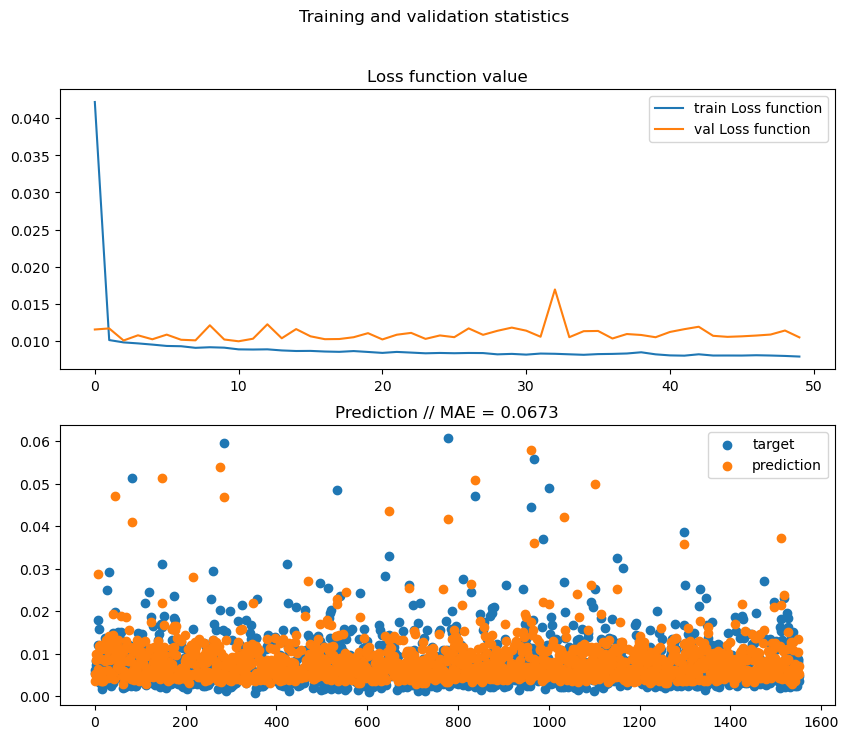

In [12]:
train_loss_fnn_MSE, val_loss_fnn_MSE = train_regressor(
    model=fnn_model_MSE,
    optimizer=optimizer,
    scaler=scaler,
    train_loader=train_dataloader,
    valid_loader=val_dataloader,
    nb_epoch=nb_epochs,
    criterion=criterion,
    batch_size=batch_size,
    device=device,
    verbose=verbose
)

### Lipschitz Neural Network

In [13]:
from models import LipschitzNN

# define the model
lnn_model_MSE = LipschitzNN(input_dim=21,
                            hidden_dim=[64, 32],
                            output_dim=1,
                            lipschitz_const=0.5,
                            nb_iterations=10,
                            group_size=2)

# batch size, need to be small enough to fit in GPU memory,
# large enough for stable gradients.
batch_size = 16

# number of workers for DataLoader, to allows parallel
# loading of data and speeds up training.
num_workers = 0

# DataLoaders
train_dataloader = DataLoader(train_tabulardataset,
                              batch_size=batch_size,
                              shuffle=True,
                              num_workers=num_workers)
val_dataloader = DataLoader(val_tabulardataset,
                            batch_size=batch_size,
                            shuffle=True,
                            num_workers=num_workers)

# Learning rate, here we use the standard one for Adam optimizer.
learning_rate = 1e-3

# Optimizer, Adam adapts learning rate per parameter,
# works well in practice for neural networks
optimizer = Adam(lnn_model_MSE.parameters(), lr=learning_rate)

# Loss function, here regression task so MSE is appropriate
criterion = nn.MSELoss()

# Device, we can use GPU if available.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Number of epochs, need enough epochs to allow convergence;
# need to adjust depending on the dataset. 
nb_epochs = 50

# Verbose
verbose = True

--------------------------------------------------------------------------------
Epoch number: 1, phase: train, Loss value: 0.1172
Epoch number: 1, phase: validation, Loss value: 0.0182
--------------------------------------------------------------------------------
Epoch number: 2, phase: train, Loss value: 0.0151
Epoch number: 2, phase: validation, Loss value: 0.0157
--------------------------------------------------------------------------------
Epoch number: 3, phase: train, Loss value: 0.0144
Epoch number: 3, phase: validation, Loss value: 0.0153
--------------------------------------------------------------------------------
Epoch number: 4, phase: train, Loss value: 0.0139
Epoch number: 4, phase: validation, Loss value: 0.0148
--------------------------------------------------------------------------------
Epoch number: 5, phase: train, Loss value: 0.0134
Epoch number: 5, phase: validation, Loss value: 0.0144
----------------------------------------------------------------------

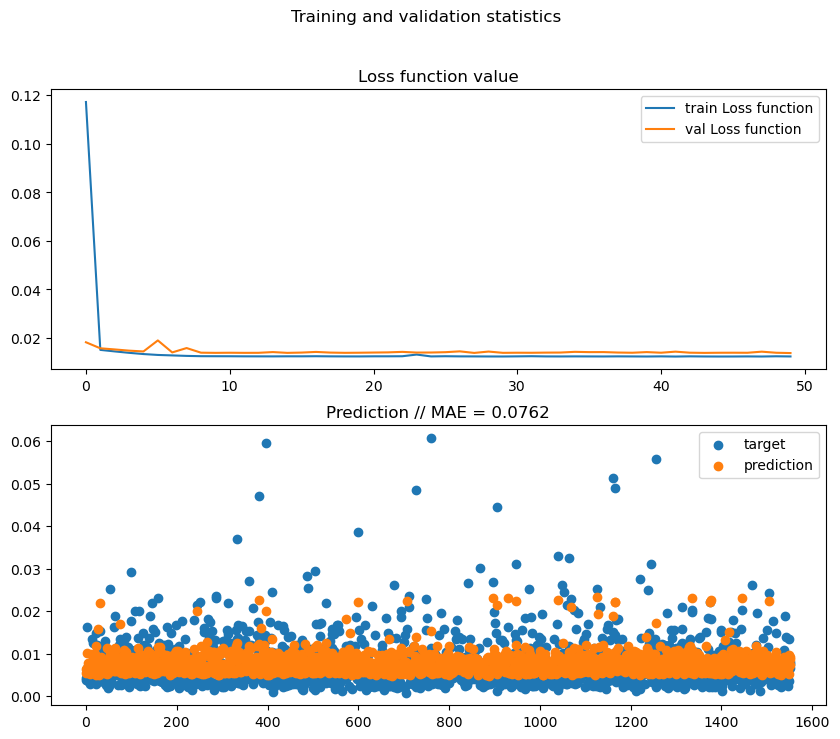

In [14]:
train_loss_lnn_MSE, val_loss_lnn_MSE = train_regressor(
    model=lnn_model_MSE,
    optimizer=optimizer,
    scaler=scaler,
    train_loader=train_dataloader,
    valid_loader=val_dataloader,
    nb_epoch=nb_epochs,
    criterion=criterion,
    batch_size=batch_size,
    device=device,
    verbose=verbose
)

### Adversarial attack

Evaluating Feedforward Neural Network robustness...
Evaluating Lipschitz Neural Network robustness...


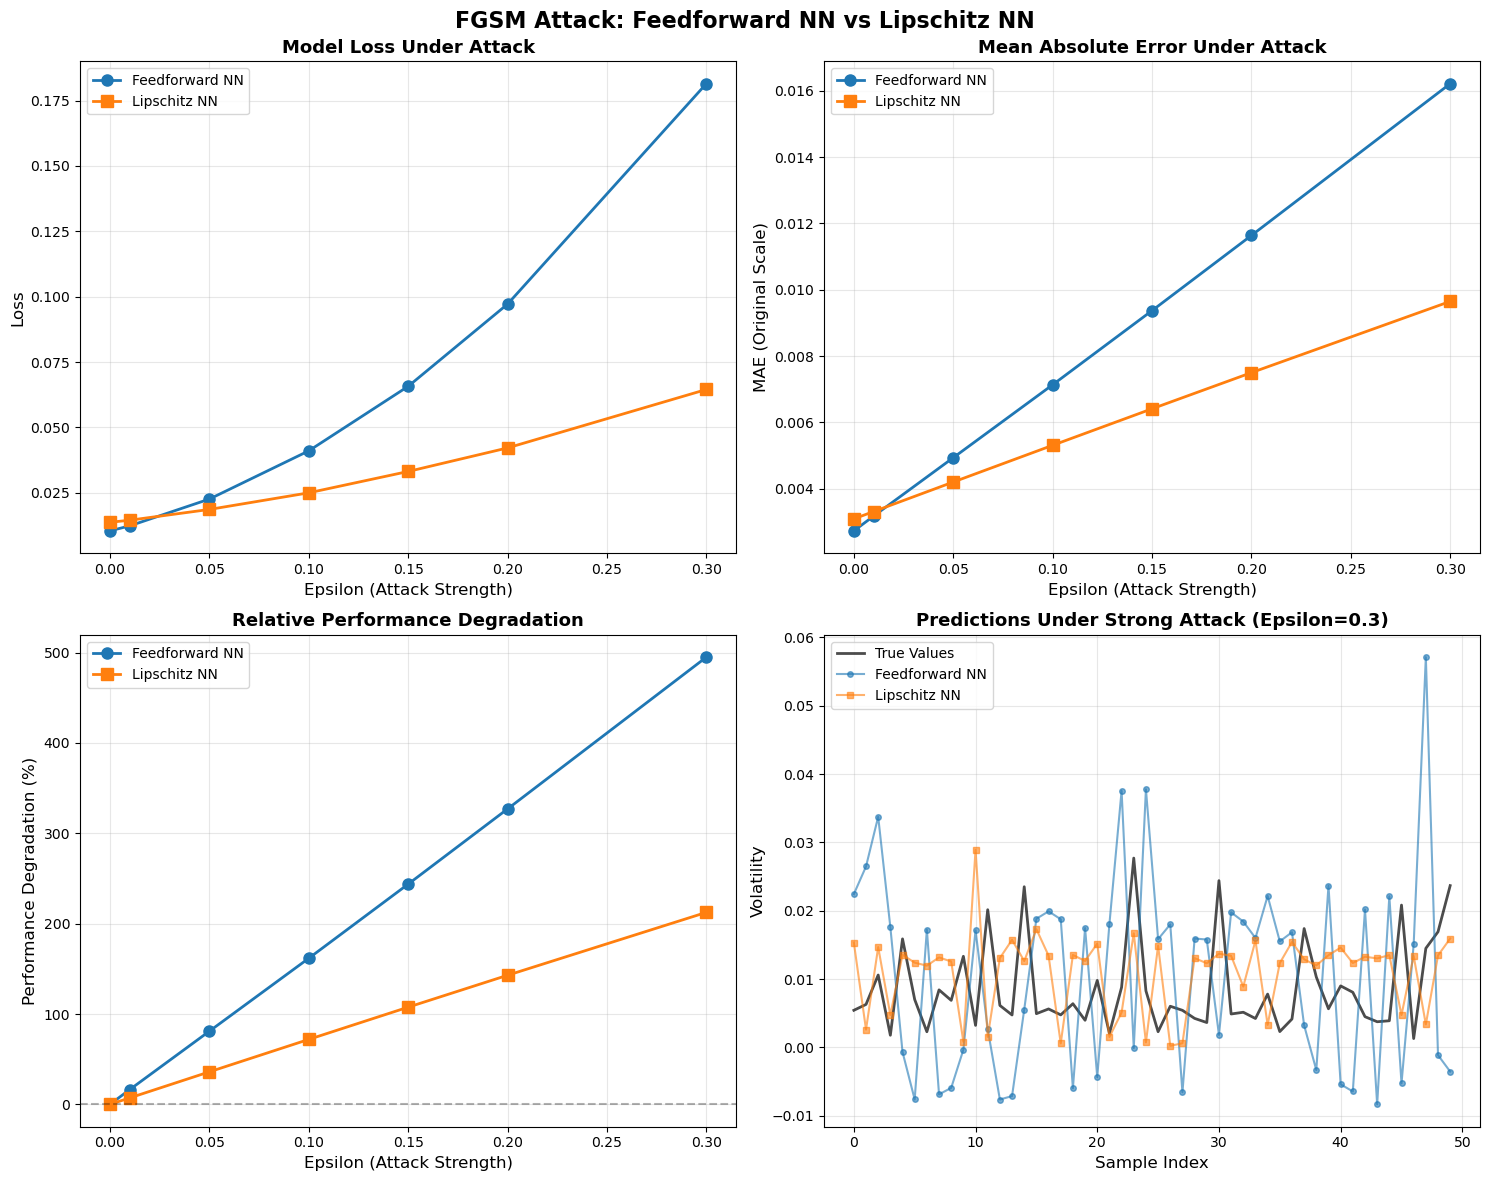


ROBUSTNESS COMPARISON SUMMARY

Epsilon    FNN Loss        LNN Loss        FNN MAE         LNN MAE        
--------------------------------------------------------------------------------
0.000      0.010407        0.013685        0.002726        0.003088       
0.010      0.012338        0.014488        0.003175        0.003310       
0.050      0.022567        0.018603        0.004934        0.004199       
0.100      0.041015        0.024959        0.007134        0.005308       
0.150      0.065691        0.033125        0.009371        0.006409       
0.200      0.097140        0.042136        0.011639        0.007500       
0.300      0.181471        0.064486        0.016218        0.009649       

Performance degradation at maximum epsilon:
Feedforward NN: 494.89%
Lipschitz NN: 212.47%
Relative improvement: 282.42%


In [15]:
from adversarial_attack import compare_model_robustness

# Define epsilon values to test (attack strengths)
epsilon_values = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3]

# Use MSE loss for attack evaluation
attack_criterion = nn.MSELoss()

# Compare robustness
fnn_attack_results, lnn_attack_results = compare_model_robustness(
    fnn_model=fnn_model_MSE,
    lnn_model=lnn_model_MSE,
    valid_loader=val_dataloader,
    criterion=attack_criterion,
    epsilon_values=epsilon_values,
    device=device,
    scaler=scaler
)